In [45]:
#Import das bibliotecas que serão usadas. Como no último EP, a biblioteca NUMBA será utilizada para 
#transformar a função principal (que usa o algoritmo de Verlet) em linguagem compilada, acelerando sua execução
import matplotlib.pyplot as plt
from Funcs import *
from numba import njit
import numpy as np

In [46]:
#Aqui, por simplicidade, tanto matemática como física, já que ficará mais fácil interpretar os resultados,
#usei unidades tais que a massa solar, a unidade astronomica e o ano terrestre valem 1. Desta forma, 
#a constante gravitacional G vale G = 4pi^2, e a massa terrestre vale aproximadamente 3*10^-6 Msol
G = 4*(np.pi**2)
M = 1

In [47]:
#Foi usado um passo de integração de 0.001 e um tempo de integração de 100.
#Este tempo de integração é razoável, pois como nas unidades utilizadas a Terra tem periodo de rotação de 1
#Então daria para a Terra dar uma centena de voltas ao redor do Sol, sendo que o segundo planeta, ao utilizar uma excentricidade de 
#0.8 (uma excentricidade bem alta, por sinal) e uma distancia ao periélio de 2, temos um periodo aproximado de 30. Assim, este tempo
#de integração é suficiente para que ambos os planetas façam ao menos 3 voltas completas
h = 0.001
T = 1

#Por simplicidade, optei por manter as distancias ao perielio, a inclinação e a fase constantes
#De forma ainda que o movimento é coplanar
inc = 0.0
r_per = 1


tempo = np.arange(0, T+h, h)

In [51]:
#Cálculo das evoluções temporais para cada parametro
Mt = 3e-6
mt = Mt*1e-3

mu = Mt/(M+Mt)
et = np.array([0.])

r02 = np.array([1/2-mu, np.sqrt(3)/2, 0])
v02 = np.sqrt((1 + et[0])*(G*M/np.linalg.norm(r02)))

fase = np.pi/3

m_arr = np.array([M, Mt, mt])
r0 = np.array([[-mu, 0, 0], [1-mu, 0, 0], r02])
v0 = np.array([[0, 0, 0], [0, np.sqrt(G), 0], [v02/np.sqrt(2), v02/np.sqrt(2), 0]])

r_, v_ = Verlet(3, m_arr, r0, v0, T, h)

r1 = r_[:, 1]
v1 = v_[:, 1]

r2 = r_[:, 2]
v2 = v_[:, 2]

m1 = Mt
m2 = m_arr[2]

E1, E2 = Energia(m1, m2, r1, r2, v1, v2)

E_arr = np.array([E1, E2])



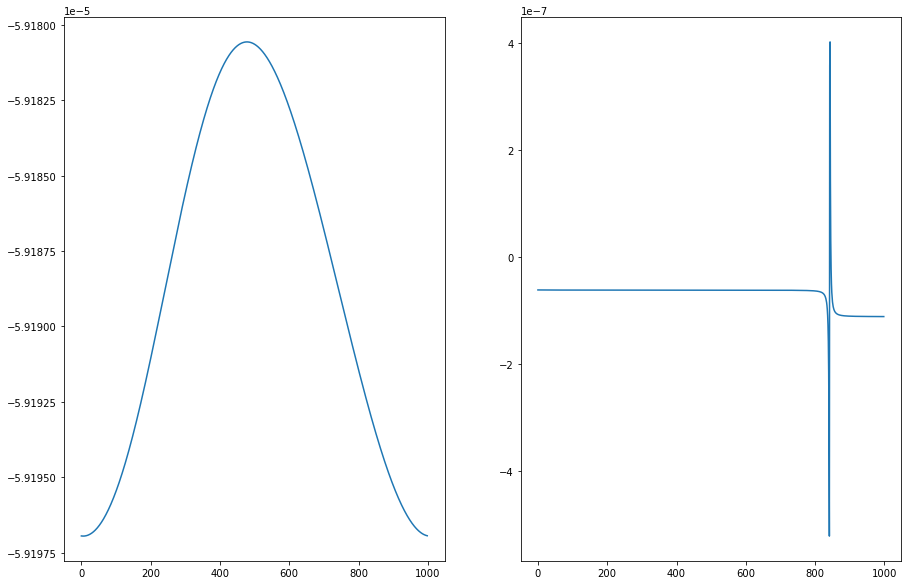

In [52]:
fig, ax = plt.subplots(1, 2, figsize = (15, 10))

for i in range(2):
    ax[i].plot(E_arr[i]) #Posições
    

plt.show()

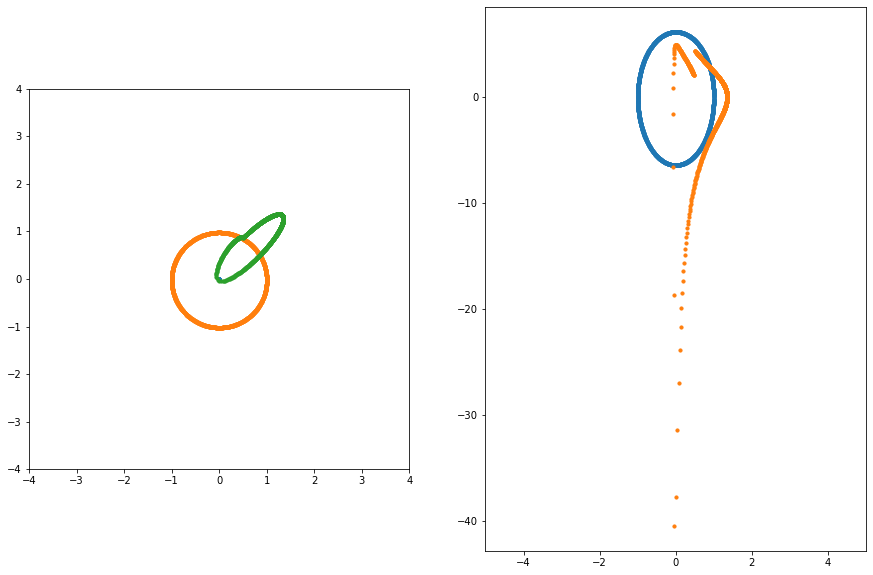

In [ ]:
fig, ax = plt.subplots(1, 2, figsize = (15, 10))

for i in range(3):
    ax[0].scatter(r_[:, i, 0], r_[:, i, 1], s = 10) #Posições
    
#plt.gca().set_aspect('equal')
ax[0].set_aspect('equal')

ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)

ax[1].scatter(r_[-len(r_)+1:, 1, 0], v_[:, 1, 0], s = 10) #Espaço de fases
ax[1].scatter(r_[-len(r_)+1:, 2, 0], v_[:, 2, 0], s = 10) #Espaço de fases

ax[1].set_xlim(-5, 5)
r_per*np.cos(inc)